# 6G Simulation Analysis Report

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


## Data Loading

In [2]:

results_dir = '/home/aung/code/docte6g/results/nr-energy-experiment-2'
scenarios = ['free_space', 'urban_macro', 'urban_micro']

flow_data_list = []
prop_node_data_list = []
energy_data_list = []

for scenario in scenarios:
    scenario_dir = os.path.join(results_dir, scenario)
    if not os.path.exists(scenario_dir):
        continue
        
    for run_dir in os.listdir(scenario_dir):
        run_path = os.path.join(scenario_dir, run_dir)
        if not os.path.isdir(run_path):
            continue
            
        parts = run_dir.split('_')
        try:
            simulator = parts[0]
            antenna = parts[2]
            load = parts[4]
            numUe = int(parts[6])
            simTime = int(parts[8])
        except:
            continue
            
        # 1. Flow Stats
        flow_file = os.path.join(run_path, f"{scenario}_flow_stats.csv")
        if os.path.exists(flow_file):
            df_flow = pd.read_csv(flow_file)
            df_flow = df_flow[df_flow['Application'] != 'control_or_unknown'].copy()
            df_flow['PacketLoss_pct'] = 100 - df_flow['DeliveryRatio_pct']
            df_flow['Simulator'] = simulator
            df_flow['Antenna'] = antenna
            df_flow['Load'] = load
            df_flow['Scenario'] = scenario
            flow_data_list.append(df_flow)
            
        # 2. Propagation Metrics
        rl_file = os.path.join(run_path, f"{scenario}_radio_link_stats.csv")
        cv_file = os.path.join(run_path, f"{scenario}_coverage_snapshot.csv")
        pg_file = os.path.join(run_path, f"{scenario}_propagation_stats.csv")
        
        if os.path.exists(cv_file):
            df_cv = pd.read_csv(cv_file)
            if os.path.exists(rl_file):
                df_rl = pd.read_csv(rl_file)
                df_rl['UeIndex'] = df_rl['Rnti'] - 1
                df_cv = df_cv.merge(df_rl[['UeIndex', 'MeanCqi', 'MeanMcs']], on='UeIndex', how='left')
            if os.path.exists(pg_file):
                df_pg = pd.read_csv(pg_file)
                pg_delay = df_pg.groupby('DstId')['Delay_ns'].mean().rename('MeanPathDelay_ns')
                df_cv = df_cv.merge(pg_delay, left_on='UeNodeId', right_index=True, how='left')
            df_cv['Antenna'] = antenna
            df_cv['Simulator'] = simulator
            df_cv['Scenario'] = scenario
            df_cv['Load'] = load
            prop_node_data_list.append(df_cv)
            
        # 3. Energy Consumption
        energy_file = os.path.join(run_path, f"{scenario}_energy_stats.csv")
        if os.path.exists(energy_file):
            df_energy_raw = pd.read_csv(energy_file)
            df_energy_raw['Power_W'] = df_energy_raw['ConsumedEnergy_J'] / df_energy_raw['Duration_s']
            
            gnb_power = df_energy_raw[df_energy_raw['Type'] == 'gNB']['Power_W'].sum()
            ue_power_avg = df_energy_raw[df_energy_raw['Type'] == 'UE']['Power_W'].mean()
            
            energy_data_list.append({
                'Scenario': scenario,
                'Simulator': simulator,
                'Antenna': antenna,
                'Load': load,
                'gNB_Power_W': gnb_power,
                'UE_Avg_Power_W': ue_power_avg
            })

df_flows = pd.concat(flow_data_list, ignore_index=True) if flow_data_list else pd.DataFrame()
df_prop_nodes = pd.concat(prop_node_data_list, ignore_index=True) if prop_node_data_list else pd.DataFrame()
df_energy = pd.DataFrame(energy_data_list)


## Cross-Scenario Comparison Summary

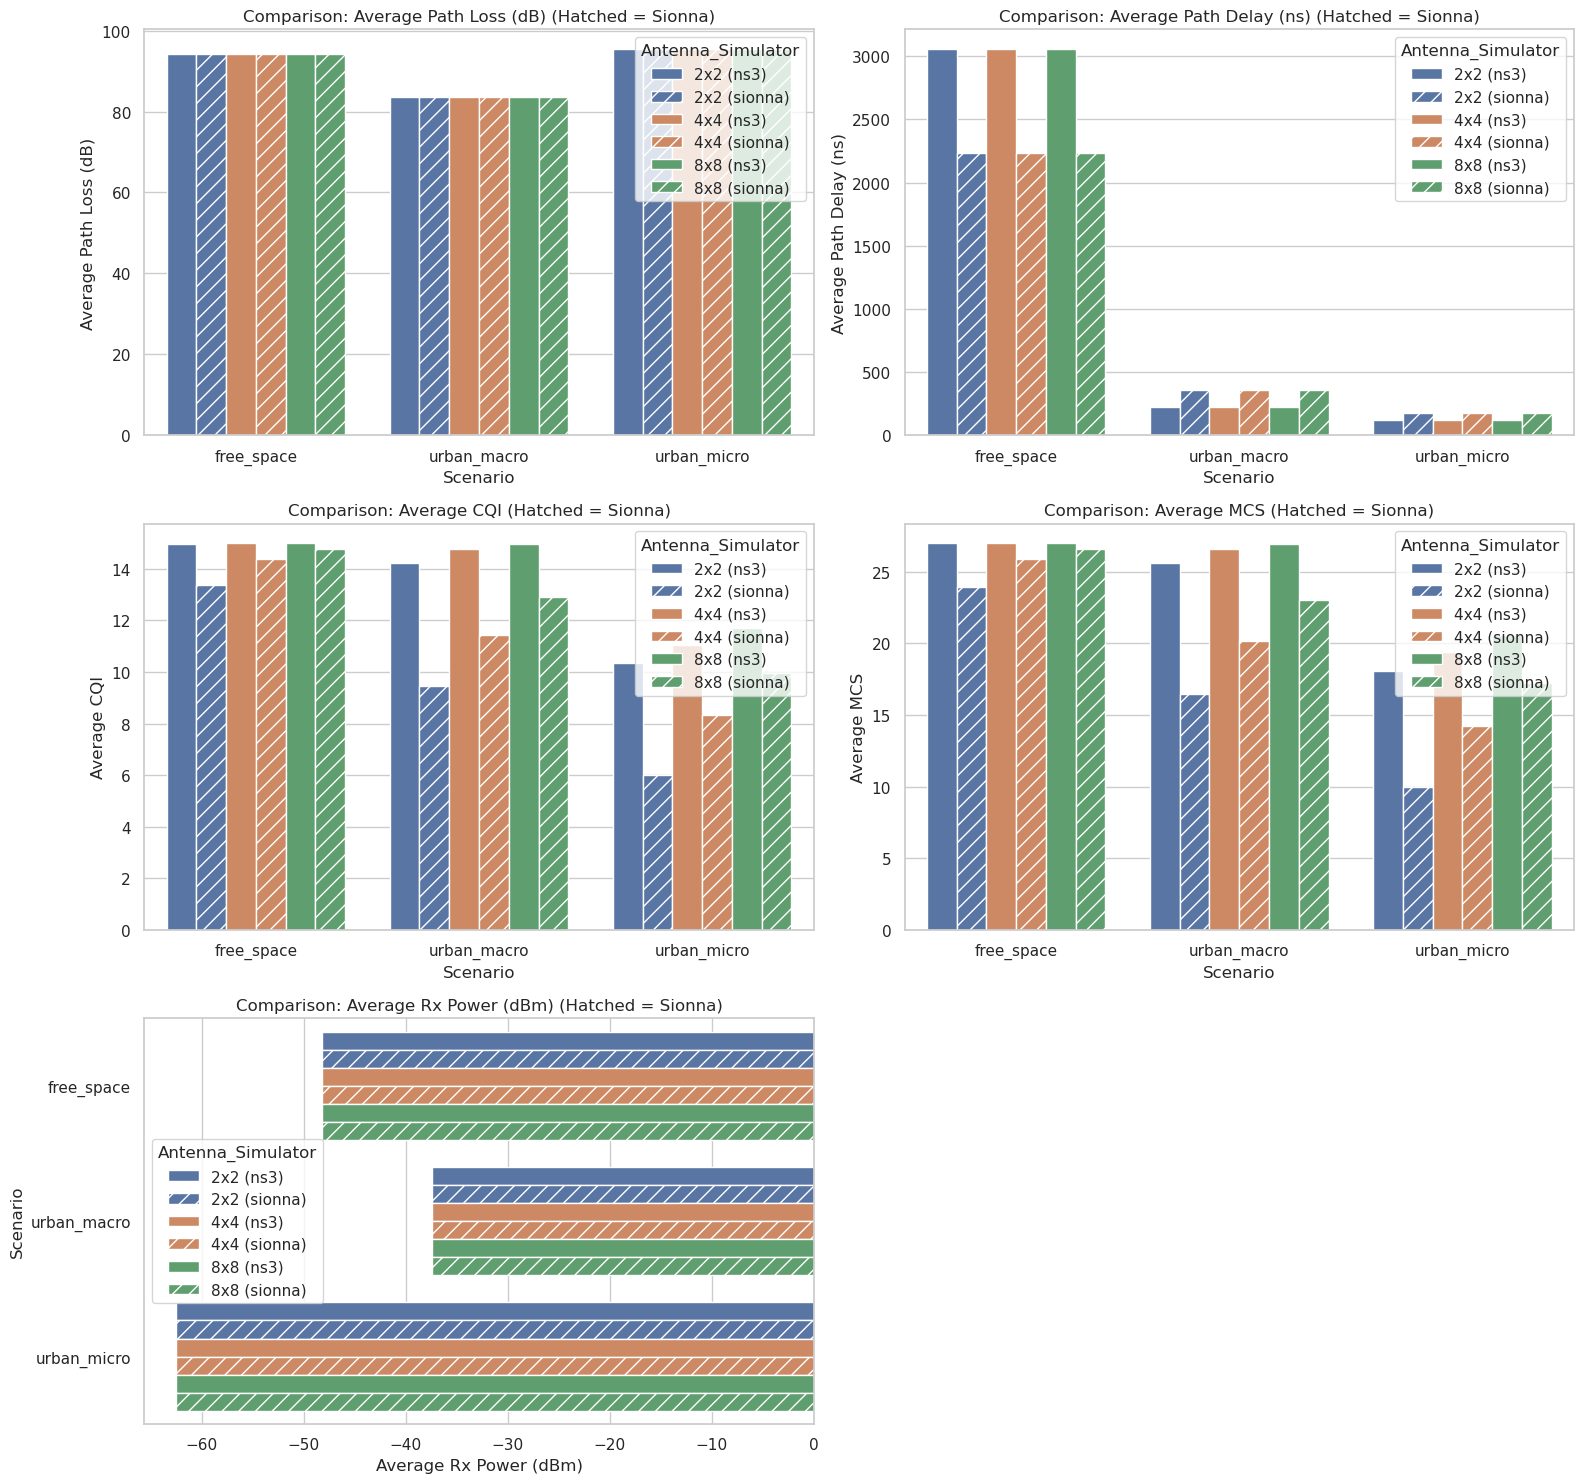

In [3]:

metrics = [
    ('FreeSpacePathloss_dB', 'Average Path Loss (dB)'),
    ('MeanPathDelay_ns', 'Average Path Delay (ns)'),
    ('MeanCqi', 'Average CQI'),
    ('MeanMcs', 'Average MCS'),
    ('EstimatedRxPower_dBm', 'Average Rx Power (dBm)')
]

hue_order_ant = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
default_colors = sns.color_palette("deep", 3)
custom_palette = [
    default_colors[0], default_colors[0],
    default_colors[1], default_colors[1],
    default_colors[2], default_colors[2]
]

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes_flat = axes.flatten()

# Combined antenna and simulator column
df_prop_nodes['Antenna_Simulator'] = df_prop_nodes['Antenna'] + ' (' + df_prop_nodes['Simulator'] + ')'

for i, (metric_col, metric_label) in enumerate(metrics):
    ax = axes_flat[i]
    if metric_col == 'EstimatedRxPower_dBm':
        sns.barplot(data=df_prop_nodes, y='Scenario', x=metric_col, hue='Antenna_Simulator', 
                    hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax)
        ax.set_xlabel(metric_label)
        ax.set_ylabel('Scenario')
    else:
        sns.barplot(data=df_prop_nodes, x='Scenario', y=metric_col, hue='Antenna_Simulator', 
                    hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax)
        ax.set_ylabel(metric_label)
        ax.set_xlabel('Scenario')
        
    # Apply hatches to distinguish Simulators
    for idx, container in enumerate(ax.containers):
        if idx < len(hue_order_ant):
            label = hue_order_ant[idx]
            hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
            for patch in container:
                patch.set_hatch(hatch)
                
    # Apply hatches to legend
    legend = ax.get_legend()
    if legend is not None:
        handles = getattr(legend, 'legend_handles', None)
        if handles is None:
            handles = getattr(legend, 'legendHandles', [])
        for idx, handle in enumerate(handles):
            if idx < len(hue_order_ant):
                label = hue_order_ant[idx]
                if 'sionna' in label or 'sionnart' in label:
                    handle.set_hatch('//')
                    
    ax.set_title(f'Comparison: {metric_label} (Hatched = Sionna)')

# Hide the empty 6th subplot
if len(metrics) < len(axes_flat):
    axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()


## Free Space Analysis

### Free Space: Propagation Metrics

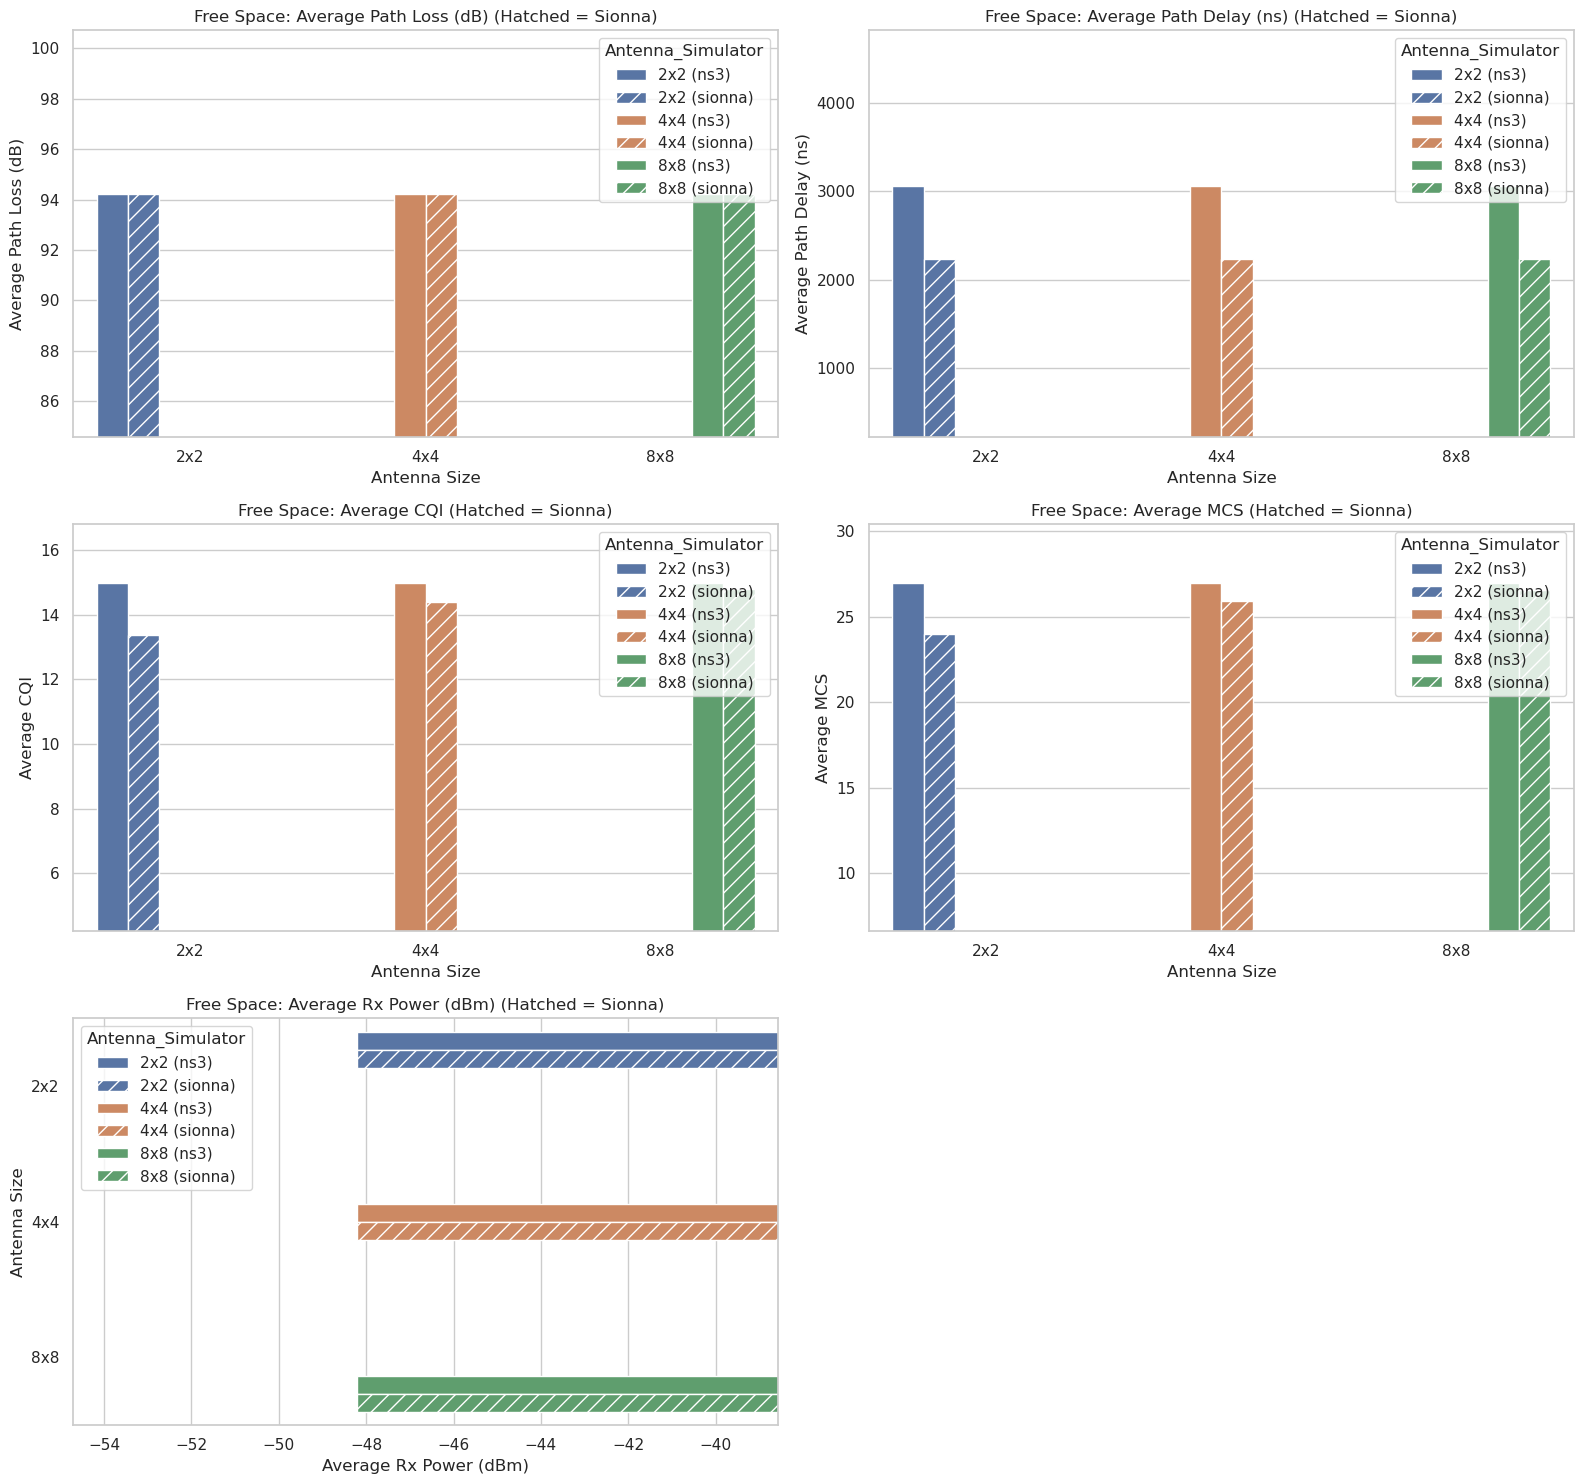

In [4]:

selected_scenario = 'free_space'
df_prop_plot = df_prop_nodes[df_prop_nodes['Scenario'] == selected_scenario].copy()
if df_prop_plot.empty:
    print(f"No propagation data for {selected_scenario}")
else:
    metrics = [
        ('FreeSpacePathloss_dB', 'Average Path Loss (dB)'),
        ('MeanPathDelay_ns', 'Average Path Delay (ns)'),
        ('MeanCqi', 'Average CQI'),
        ('MeanMcs', 'Average MCS'),
        ('EstimatedRxPower_dBm', 'Average Rx Power (dBm)')
    ]
    antenna_order = ['2x2', '4x4', '8x8']
    
    hue_order_ant = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    axes_flat = axes.flatten()
    
    # Combined antenna and simulator column
    df_prop_plot['Antenna_Simulator'] = df_prop_plot['Antenna'] + ' (' + df_prop_plot['Simulator'] + ')'
    
    for i, (metric_col, metric_label) in enumerate(metrics):
        ax = axes_flat[i]
        
        # Calculate dynamic limits to highlight differences
        data_values = df_prop_plot[metric_col].dropna()
        if not data_values.empty:
            v_min, v_max = data_values.min(), data_values.max()
            v_range = v_max - v_min
            padding = v_range * 0.2 if v_range > 0 else abs(v_max) * 0.1 if v_max != 0 else 1.0
            
        if metric_col == 'EstimatedRxPower_dBm':
            # Horizontal orientation for Rx Power
            sns.barplot(data=df_prop_plot, y='Antenna', x=metric_col, order=antenna_order, 
                        hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax)
            ax.set_xlabel(metric_label)
            ax.set_ylabel('Antenna Size')
            if not data_values.empty:
                ax.set_xlim(v_min - padding, v_max + padding)
        else:
            # Vertical orientation for others
            sns.barplot(data=df_prop_plot, x='Antenna', y=metric_col, order=antenna_order, 
                        hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax)
            ax.set_ylabel(metric_label)
            ax.set_xlabel('Antenna Size')
            if not data_values.empty:
                ax.set_ylim(v_min - padding, v_max + padding)
                
        # Apply hatches to distinguish Simulators
        for idx, container in enumerate(ax.containers):
            if idx < len(hue_order_ant):
                label = hue_order_ant[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
                    
        # Apply hatches to legend
        legend = ax.get_legend()
        if legend is not None:
            handles = getattr(legend, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_ant):
                    label = hue_order_ant[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} (Hatched = Sionna)')
    
    # Hide the empty 6th subplot
    if len(metrics) < len(axes_flat):
        axes_flat[-1].set_visible(False)
        
    plt.tight_layout()
    plt.show()


### Free Space: Flow Metrics

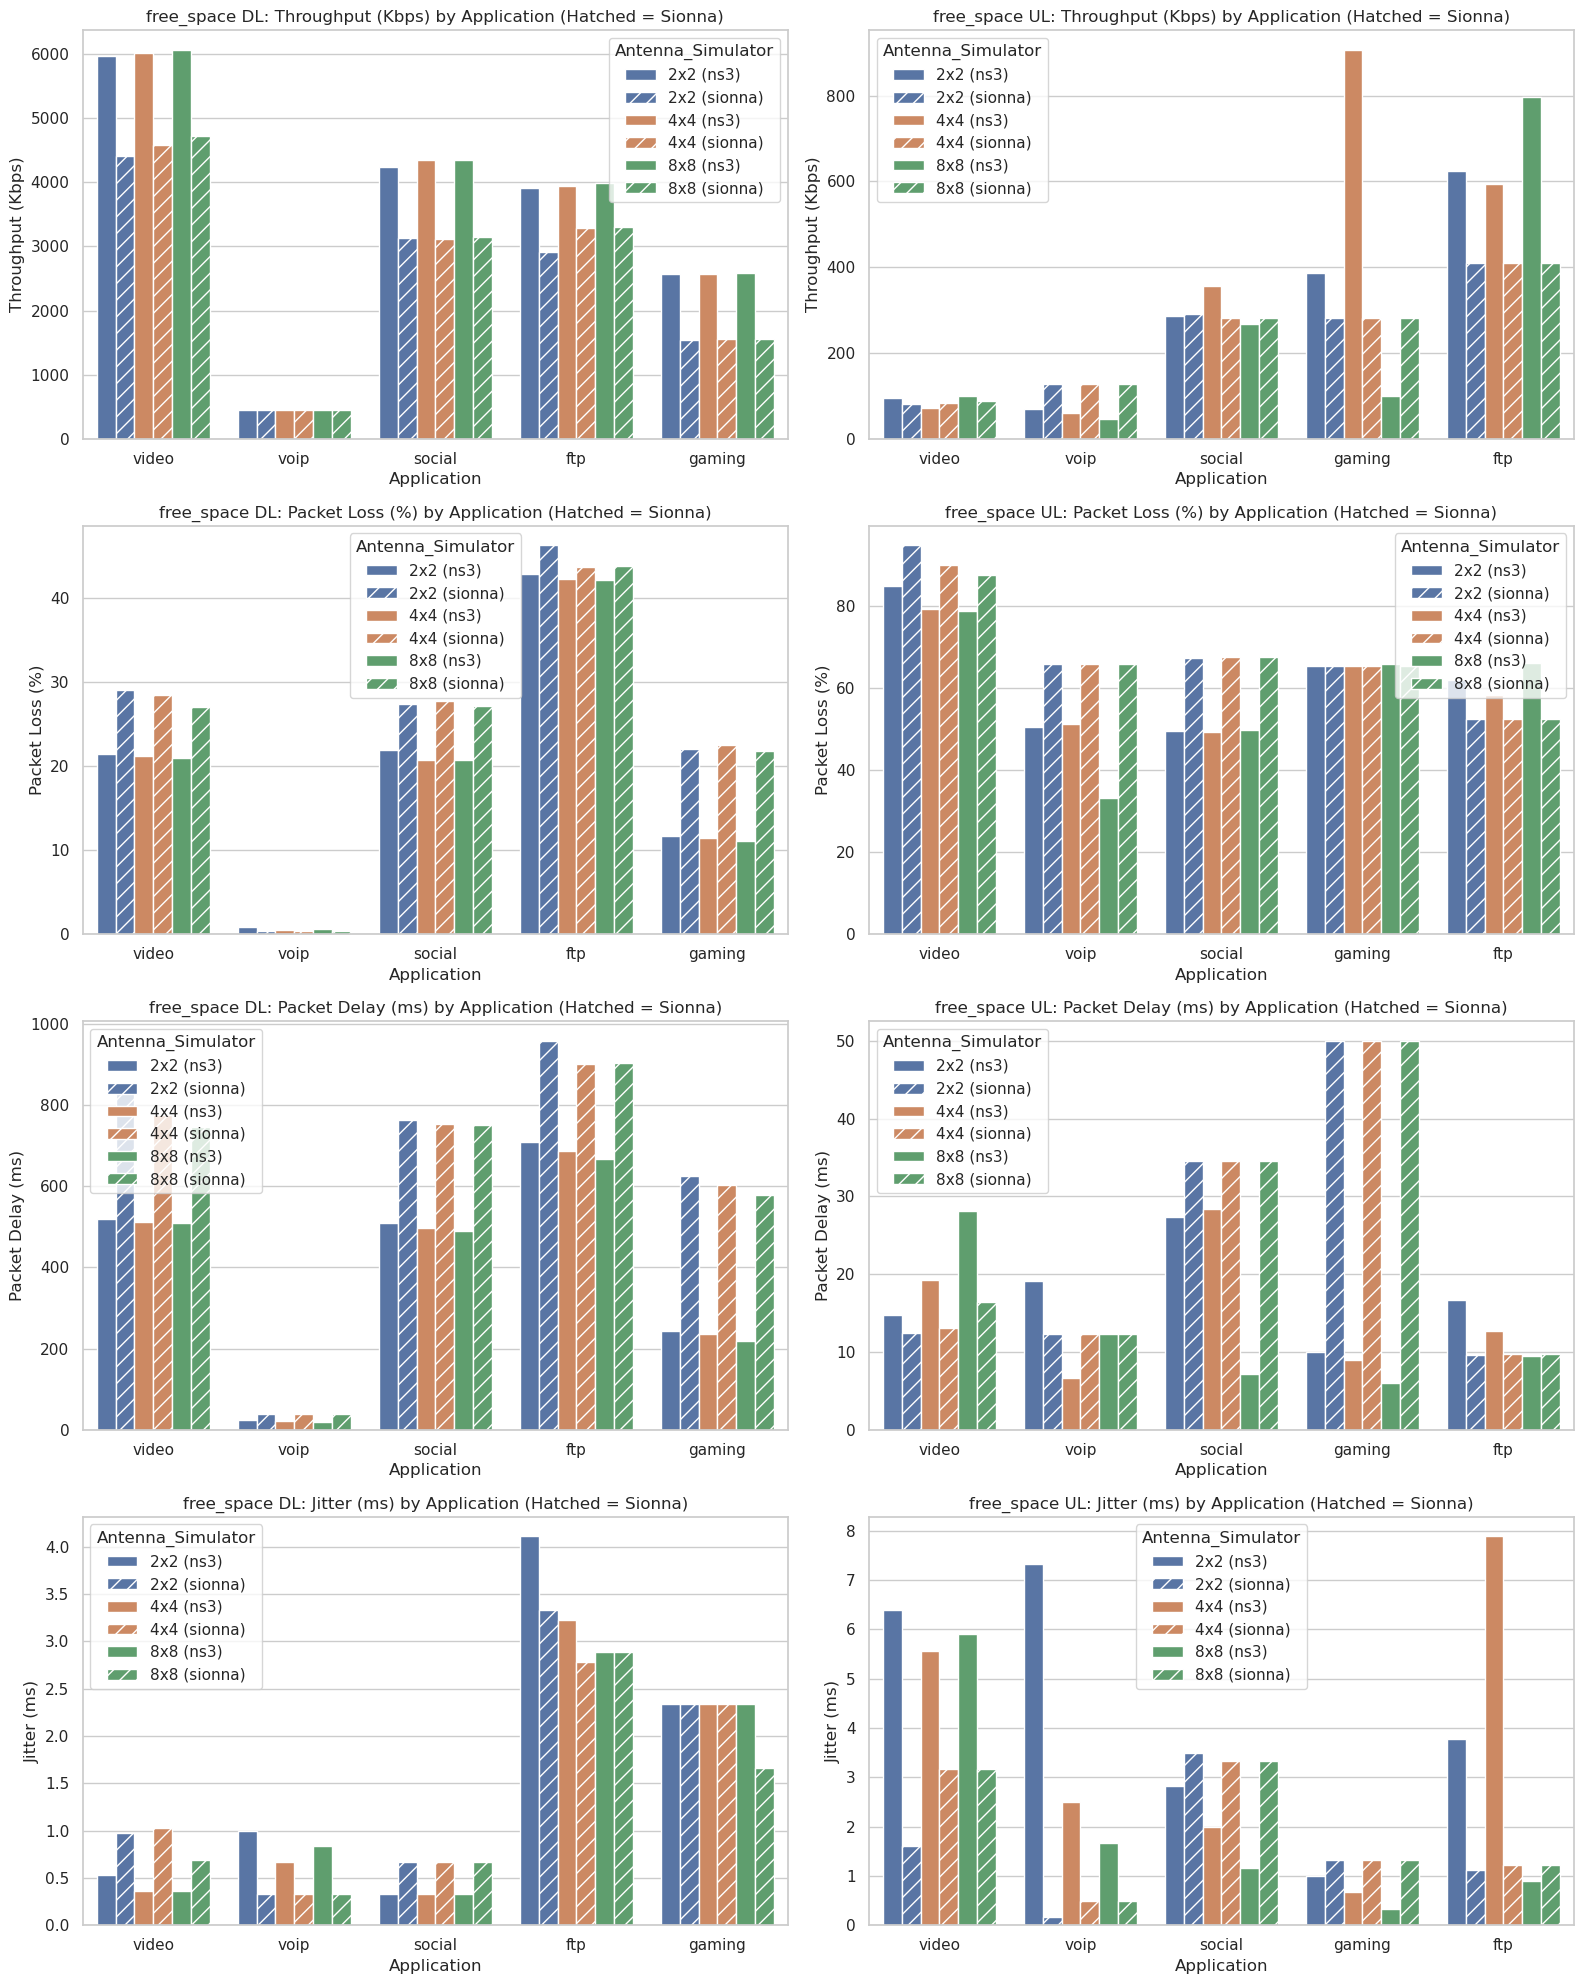

In [5]:

selected_scenario = 'free_space'
df_flow_plot = df_flows[df_flows['Scenario'] == selected_scenario].copy()
if df_flow_plot.empty:
    print(f"No flow data for {selected_scenario}")
else:
    metrics = [
        ('Throughput_Kbps', 'Throughput (Kbps)'),
        ('PacketLoss_pct', 'Packet Loss (%)'),
        ('Delay_ms', 'Packet Delay (ms)'),
        ('Jitter_ms', 'Jitter (ms)')
    ]
    directions = ['DL', 'UL']
    hue_order = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]
    
    fig, axes = plt.subplots(len(metrics), 2, figsize=(16, 5 * len(metrics)))
    for i, (metric_col, metric_label) in enumerate(metrics):
        for j, direction in enumerate(directions):
            ax = axes[i, j]
            df_plot = df_flow_plot[df_flow_plot['Direction'] == direction].copy()
            if df_plot.empty:
                ax.set_title(f'{selected_scenario} {direction}: No Data')
                continue
            
            # Combine Antenna and Simulator for grouped bar plot
            df_plot['Antenna_Simulator'] = df_plot['Antenna'] + ' (' + df_plot['Simulator'] + ')'
            
            sns.barplot(data=df_plot, x='Application', y=metric_col, hue='Antenna_Simulator', 
                        hue_order=hue_order, palette=custom_palette, errorbar=None, ax=ax)
            
            # Apply hatches to distinguish Simulators
            for idx, container in enumerate(ax.containers):
                if idx < len(hue_order):
                    label = hue_order[idx]
                    hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                    for patch in container:
                        patch.set_hatch(hatch)
            
            # Apply hatches to legend
            legend = ax.get_legend()
            if legend is not None:
                handles = getattr(legend, 'legend_handles', None)
                if handles is None:
                    handles = getattr(legend, 'legendHandles', [])
                for idx, handle in enumerate(handles):
                    if idx < len(hue_order):
                        label = hue_order[idx]
                        if 'sionna' in label or 'sionnart' in label:
                            handle.set_hatch('//')
            
            ax.set_title(f'{selected_scenario} {direction}: {metric_label} by Application (Hatched = Sionna)')
            ax.set_ylabel(metric_label)
    plt.tight_layout()
    plt.show()


### Free Space: Power Consumption

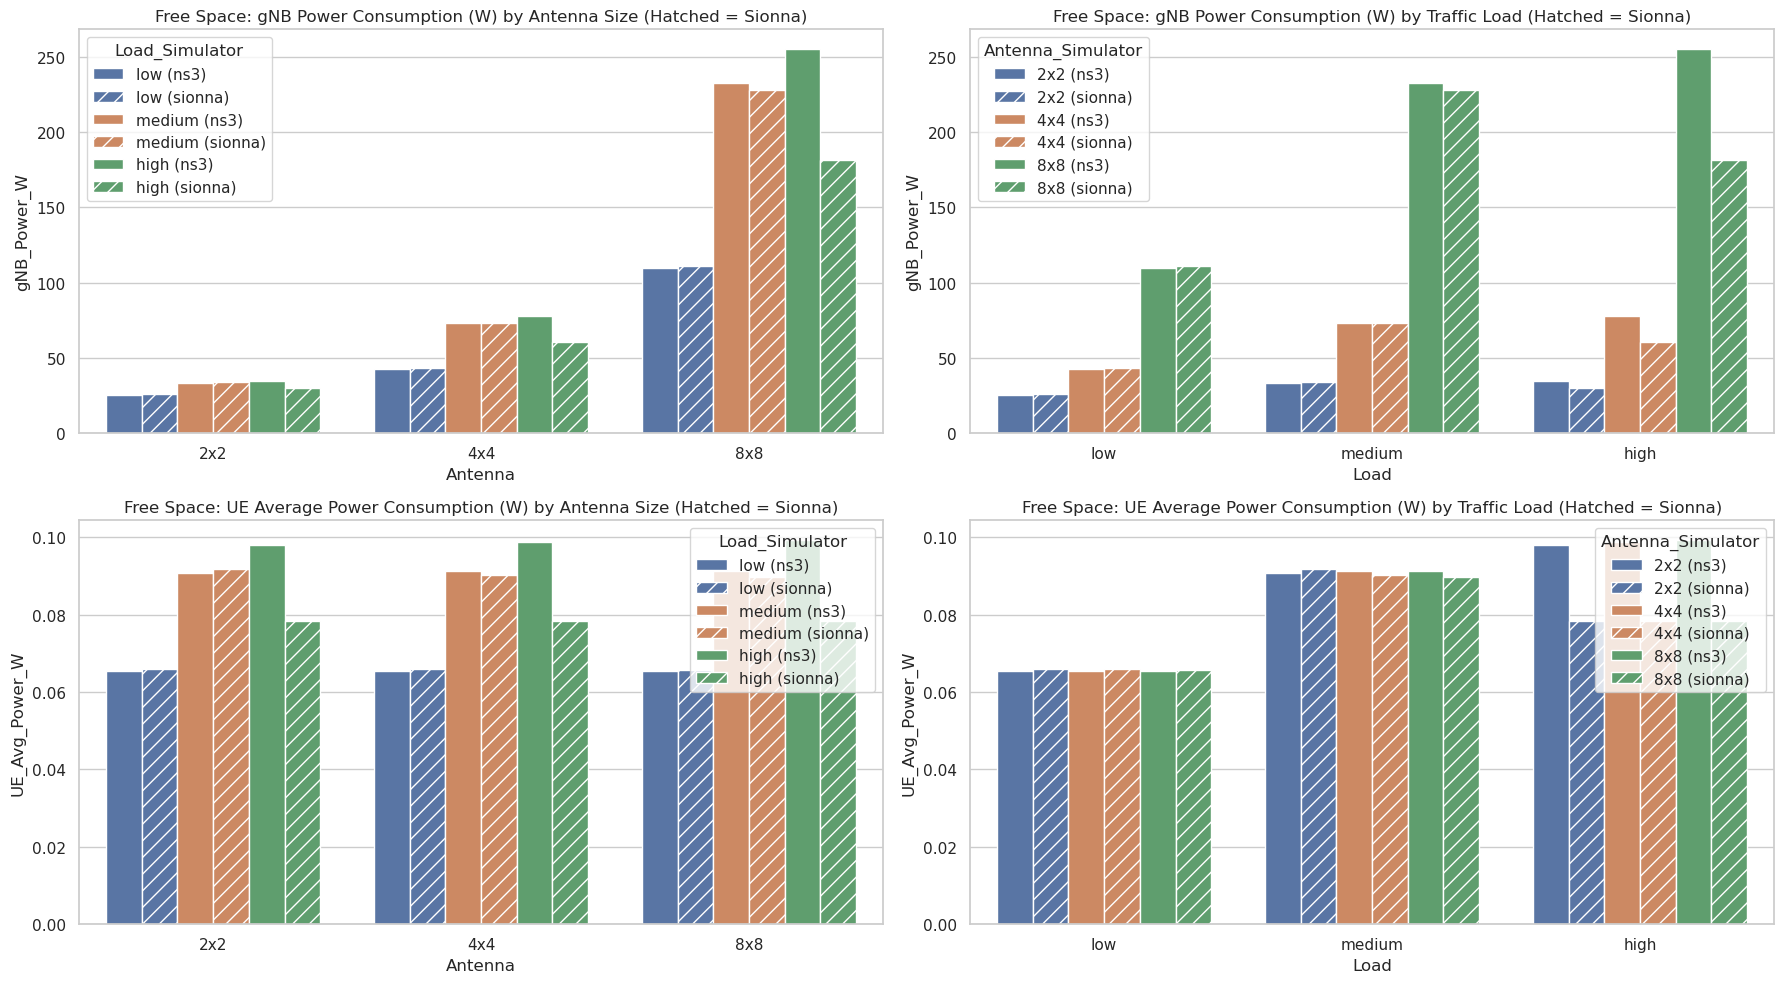

In [6]:

selected_scenario = 'free_space'
df_energy_scenario = df_energy[df_energy['Scenario'] == selected_scenario].copy()
if df_energy_scenario.empty:
    print(f"No energy data for {selected_scenario}")
else:
    metrics = [
        ('gNB_Power_W', 'gNB Power Consumption (W)'),
        ('UE_Avg_Power_W', 'UE Average Power Consumption (W)')
    ]
    antenna_order = ['2x2', '4x4', '8x8']
    load_order = ['low', 'medium', 'high']
    
    hue_order_load = ['low (ns3)', 'low (sionna)', 'medium (ns3)', 'medium (sionna)', 'high (ns3)', 'high (sionna)']
    hue_order_ant = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]

    fig, axes = plt.subplots(len(metrics), 2, figsize=(18, 5 * len(metrics)))

    for i, (metric_col, metric_label) in enumerate(metrics):
        # Combined load and simulator column
        df_energy_scenario['Load_Simulator'] = df_energy_scenario['Load'] + ' (' + df_energy_scenario['Simulator'] + ')'
        
        # Plot 1: by Antenna Size (hue is Load + Simulator)
        ax1 = axes[i, 0]
        sns.barplot(data=df_energy_scenario, x='Antenna', y=metric_col, order=antenna_order, 
                    hue='Load_Simulator', hue_order=hue_order_load, palette=custom_palette, errorbar=None, ax=ax1)
        
        # Apply hatches to distinguish Simulators in Plot 1
        for idx, container in enumerate(ax1.containers):
            if idx < len(hue_order_load):
                label = hue_order_load[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
        
        # Apply hatches to legend of Plot 1
        legend1 = ax1.get_legend()
        if legend1 is not None:
            handles = getattr(legend1, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend1, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_load):
                    label = hue_order_load[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax1.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} by Antenna Size (Hatched = Sionna)')
        
        # Combined antenna and simulator column
        df_energy_scenario['Antenna_Simulator'] = df_energy_scenario['Antenna'] + ' (' + df_energy_scenario['Simulator'] + ')'
        
        # Plot 2: by Traffic Load (hue is Antenna + Simulator)
        ax2 = axes[i, 1]
        sns.barplot(data=df_energy_scenario, x='Load', y=metric_col, order=load_order, 
                    hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax2)
        
        # Apply hatches to distinguish Simulators in Plot 2
        for idx, container in enumerate(ax2.containers):
            if idx < len(hue_order_ant):
                label = hue_order_ant[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
                    
        # Apply hatches to legend of Plot 2
        legend2 = ax2.get_legend()
        if legend2 is not None:
            handles = getattr(legend2, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend2, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_ant):
                    label = hue_order_ant[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax2.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} by Traffic Load (Hatched = Sionna)')

    plt.tight_layout()
    plt.show()


## Urban Micro Analysis

### Urban Micro: Propagation Metrics

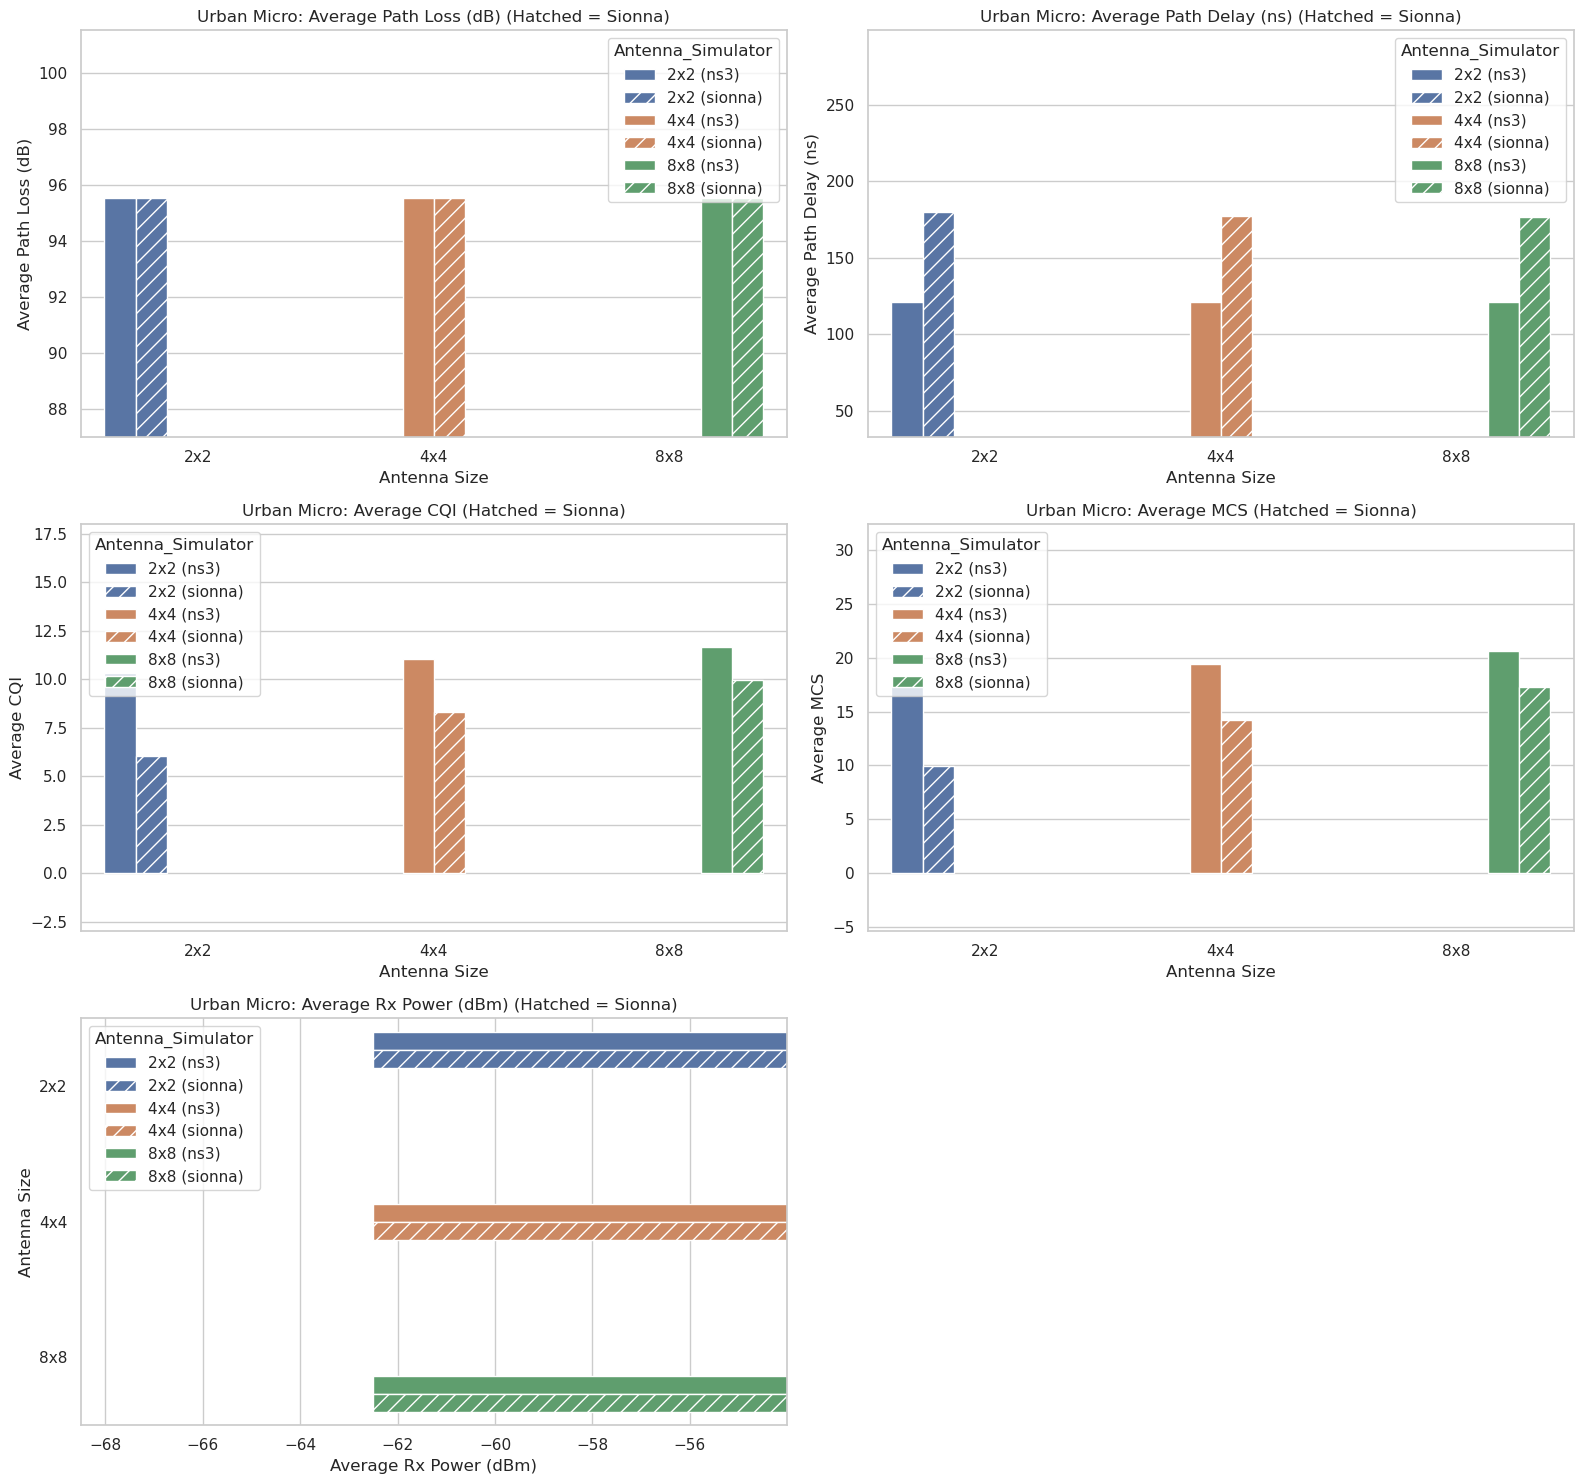

In [7]:

selected_scenario = 'urban_micro'
df_prop_plot = df_prop_nodes[df_prop_nodes['Scenario'] == selected_scenario].copy()
if df_prop_plot.empty:
    print(f"No propagation data for {selected_scenario}")
else:
    metrics = [
        ('FreeSpacePathloss_dB', 'Average Path Loss (dB)'),
        ('MeanPathDelay_ns', 'Average Path Delay (ns)'),
        ('MeanCqi', 'Average CQI'),
        ('MeanMcs', 'Average MCS'),
        ('EstimatedRxPower_dBm', 'Average Rx Power (dBm)')
    ]
    antenna_order = ['2x2', '4x4', '8x8']
    
    hue_order_ant = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    axes_flat = axes.flatten()
    
    # Combined antenna and simulator column
    df_prop_plot['Antenna_Simulator'] = df_prop_plot['Antenna'] + ' (' + df_prop_plot['Simulator'] + ')'
    
    for i, (metric_col, metric_label) in enumerate(metrics):
        ax = axes_flat[i]
        
        # Calculate dynamic limits to highlight differences
        data_values = df_prop_plot[metric_col].dropna()
        if not data_values.empty:
            v_min, v_max = data_values.min(), data_values.max()
            v_range = v_max - v_min
            padding = v_range * 0.2 if v_range > 0 else abs(v_max) * 0.1 if v_max != 0 else 1.0
            
        if metric_col == 'EstimatedRxPower_dBm':
            # Horizontal orientation for Rx Power
            sns.barplot(data=df_prop_plot, y='Antenna', x=metric_col, order=antenna_order, 
                        hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax)
            ax.set_xlabel(metric_label)
            ax.set_ylabel('Antenna Size')
            if not data_values.empty:
                ax.set_xlim(v_min - padding, v_max + padding)
        else:
            # Vertical orientation for others
            sns.barplot(data=df_prop_plot, x='Antenna', y=metric_col, order=antenna_order, 
                        hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax)
            ax.set_ylabel(metric_label)
            ax.set_xlabel('Antenna Size')
            if not data_values.empty:
                ax.set_ylim(v_min - padding, v_max + padding)
                
        # Apply hatches to distinguish Simulators
        for idx, container in enumerate(ax.containers):
            if idx < len(hue_order_ant):
                label = hue_order_ant[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
                    
        # Apply hatches to legend
        legend = ax.get_legend()
        if legend is not None:
            handles = getattr(legend, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_ant):
                    label = hue_order_ant[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} (Hatched = Sionna)')
    
    # Hide the empty 6th subplot
    if len(metrics) < len(axes_flat):
        axes_flat[-1].set_visible(False)
        
    plt.tight_layout()
    plt.show()


### Urban Micro: Flow Metrics

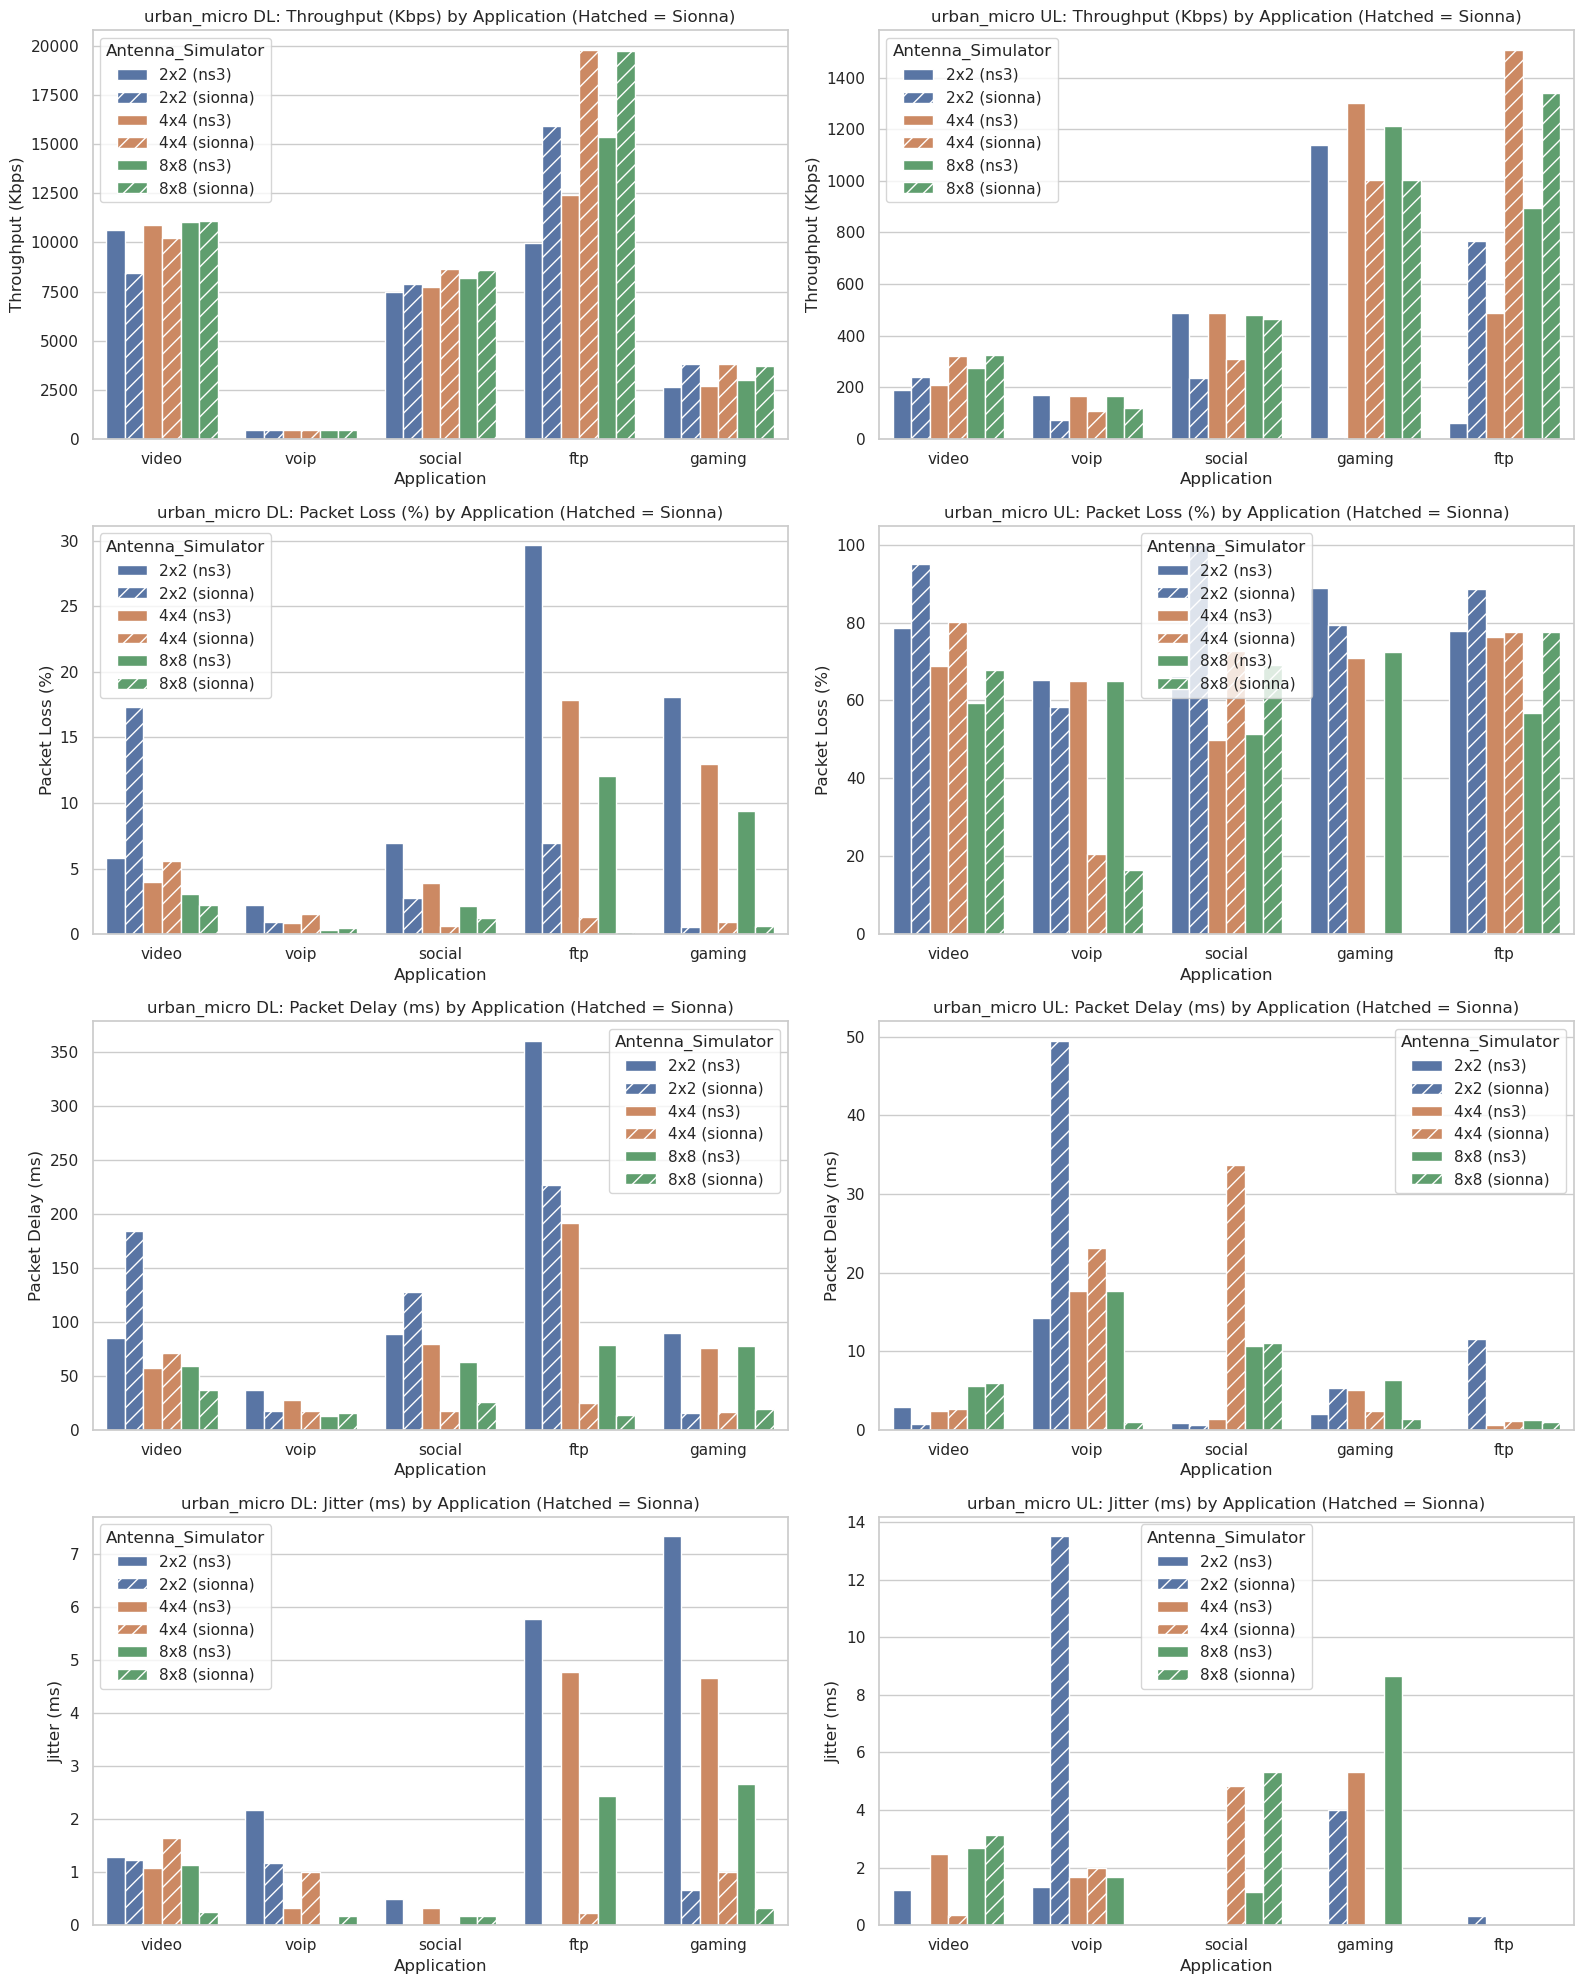

In [8]:

selected_scenario = 'urban_micro'
df_flow_plot = df_flows[df_flows['Scenario'] == selected_scenario].copy()
if df_flow_plot.empty:
    print(f"No flow data for {selected_scenario}")
else:
    metrics = [
        ('Throughput_Kbps', 'Throughput (Kbps)'),
        ('PacketLoss_pct', 'Packet Loss (%)'),
        ('Delay_ms', 'Packet Delay (ms)'),
        ('Jitter_ms', 'Jitter (ms)')
    ]
    directions = ['DL', 'UL']
    hue_order = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]
    
    fig, axes = plt.subplots(len(metrics), 2, figsize=(16, 5 * len(metrics)))
    for i, (metric_col, metric_label) in enumerate(metrics):
        for j, direction in enumerate(directions):
            ax = axes[i, j]
            df_plot = df_flow_plot[df_flow_plot['Direction'] == direction].copy()
            if df_plot.empty:
                ax.set_title(f'{selected_scenario} {direction}: No Data')
                continue
            
            # Combine Antenna and Simulator for grouped bar plot
            df_plot['Antenna_Simulator'] = df_plot['Antenna'] + ' (' + df_plot['Simulator'] + ')'
            
            sns.barplot(data=df_plot, x='Application', y=metric_col, hue='Antenna_Simulator', 
                        hue_order=hue_order, palette=custom_palette, errorbar=None, ax=ax)
            
            # Apply hatches to distinguish Simulators
            for idx, container in enumerate(ax.containers):
                if idx < len(hue_order):
                    label = hue_order[idx]
                    hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                    for patch in container:
                        patch.set_hatch(hatch)
            
            # Apply hatches to legend
            legend = ax.get_legend()
            if legend is not None:
                handles = getattr(legend, 'legend_handles', None)
                if handles is None:
                    handles = getattr(legend, 'legendHandles', [])
                for idx, handle in enumerate(handles):
                    if idx < len(hue_order):
                        label = hue_order[idx]
                        if 'sionna' in label or 'sionnart' in label:
                            handle.set_hatch('//')
            
            ax.set_title(f'{selected_scenario} {direction}: {metric_label} by Application (Hatched = Sionna)')
            ax.set_ylabel(metric_label)
    plt.tight_layout()
    plt.show()


### Urban Micro: Power Consumption

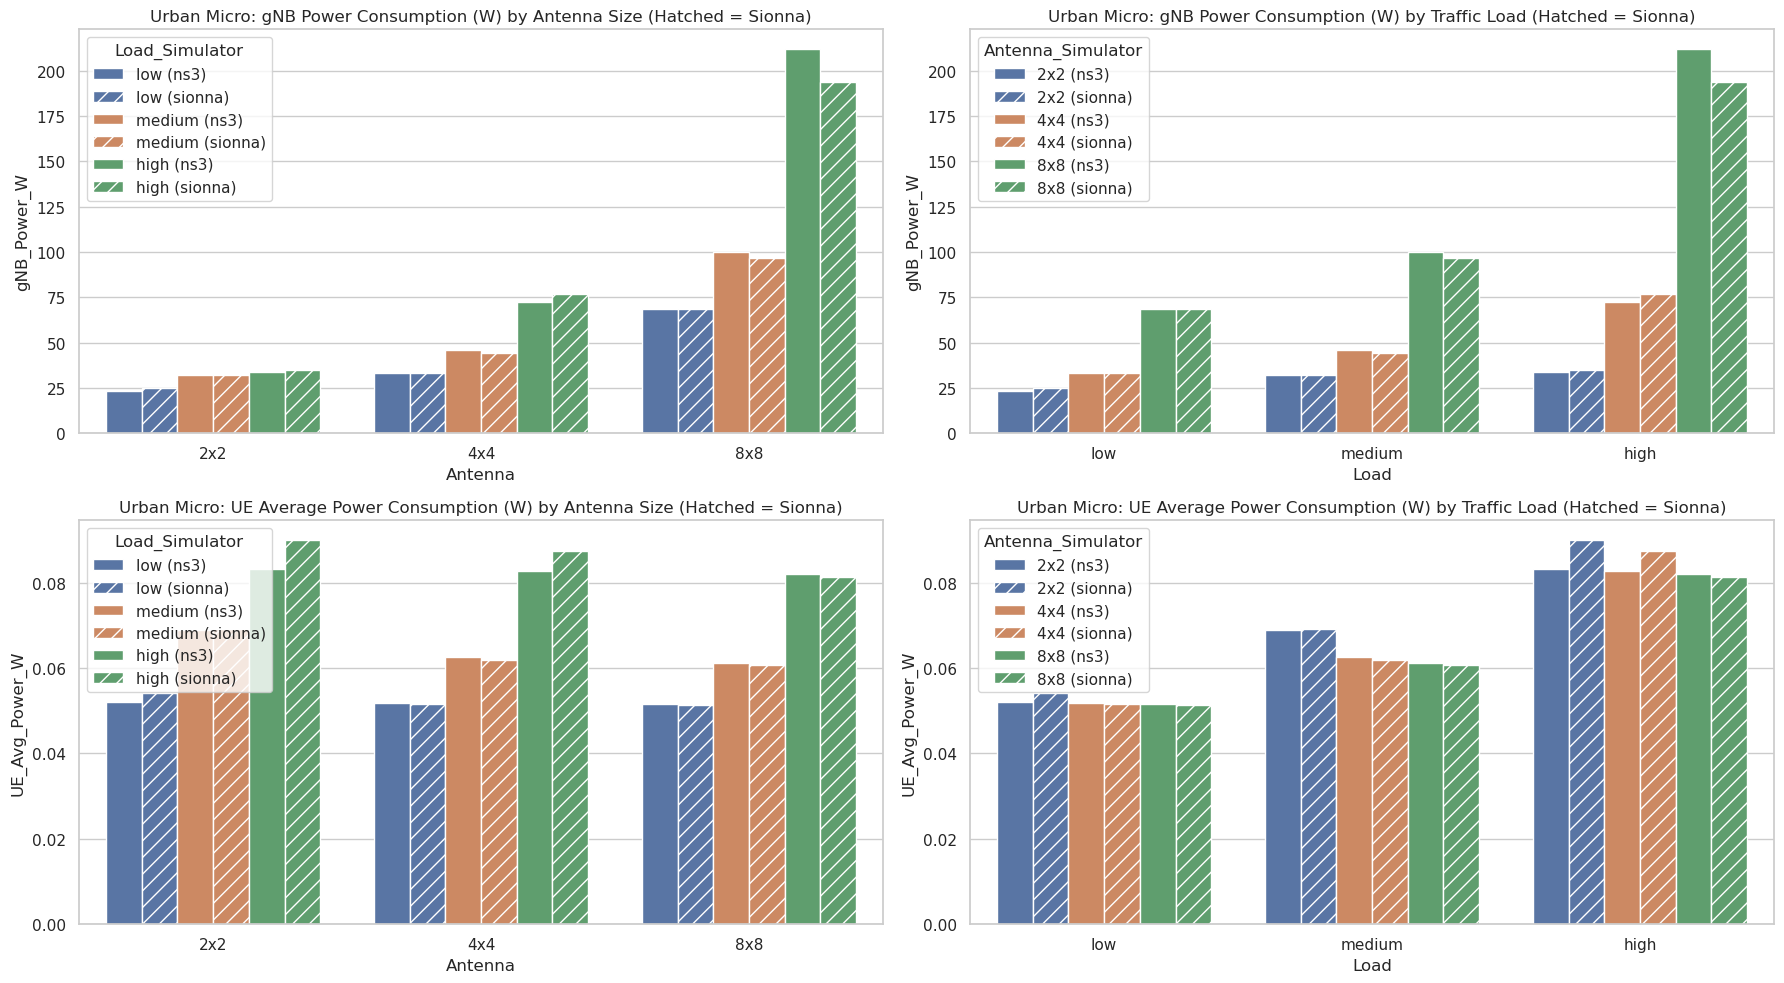

In [9]:

selected_scenario = 'urban_micro'
df_energy_scenario = df_energy[df_energy['Scenario'] == selected_scenario].copy()
if df_energy_scenario.empty:
    print(f"No energy data for {selected_scenario}")
else:
    metrics = [
        ('gNB_Power_W', 'gNB Power Consumption (W)'),
        ('UE_Avg_Power_W', 'UE Average Power Consumption (W)')
    ]
    antenna_order = ['2x2', '4x4', '8x8']
    load_order = ['low', 'medium', 'high']
    
    hue_order_load = ['low (ns3)', 'low (sionna)', 'medium (ns3)', 'medium (sionna)', 'high (ns3)', 'high (sionna)']
    hue_order_ant = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]

    fig, axes = plt.subplots(len(metrics), 2, figsize=(18, 5 * len(metrics)))

    for i, (metric_col, metric_label) in enumerate(metrics):
        # Combined load and simulator column
        df_energy_scenario['Load_Simulator'] = df_energy_scenario['Load'] + ' (' + df_energy_scenario['Simulator'] + ')'
        
        # Plot 1: by Antenna Size (hue is Load + Simulator)
        ax1 = axes[i, 0]
        sns.barplot(data=df_energy_scenario, x='Antenna', y=metric_col, order=antenna_order, 
                    hue='Load_Simulator', hue_order=hue_order_load, palette=custom_palette, errorbar=None, ax=ax1)
        
        # Apply hatches to distinguish Simulators in Plot 1
        for idx, container in enumerate(ax1.containers):
            if idx < len(hue_order_load):
                label = hue_order_load[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
        
        # Apply hatches to legend of Plot 1
        legend1 = ax1.get_legend()
        if legend1 is not None:
            handles = getattr(legend1, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend1, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_load):
                    label = hue_order_load[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax1.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} by Antenna Size (Hatched = Sionna)')
        
        # Combined antenna and simulator column
        df_energy_scenario['Antenna_Simulator'] = df_energy_scenario['Antenna'] + ' (' + df_energy_scenario['Simulator'] + ')'
        
        # Plot 2: by Traffic Load (hue is Antenna + Simulator)
        ax2 = axes[i, 1]
        sns.barplot(data=df_energy_scenario, x='Load', y=metric_col, order=load_order, 
                    hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax2)
        
        # Apply hatches to distinguish Simulators in Plot 2
        for idx, container in enumerate(ax2.containers):
            if idx < len(hue_order_ant):
                label = hue_order_ant[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
                    
        # Apply hatches to legend of Plot 2
        legend2 = ax2.get_legend()
        if legend2 is not None:
            handles = getattr(legend2, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend2, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_ant):
                    label = hue_order_ant[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax2.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} by Traffic Load (Hatched = Sionna)')

    plt.tight_layout()
    plt.show()


## Urban Macro Analysis

### Urban Macro: Propagation Metrics

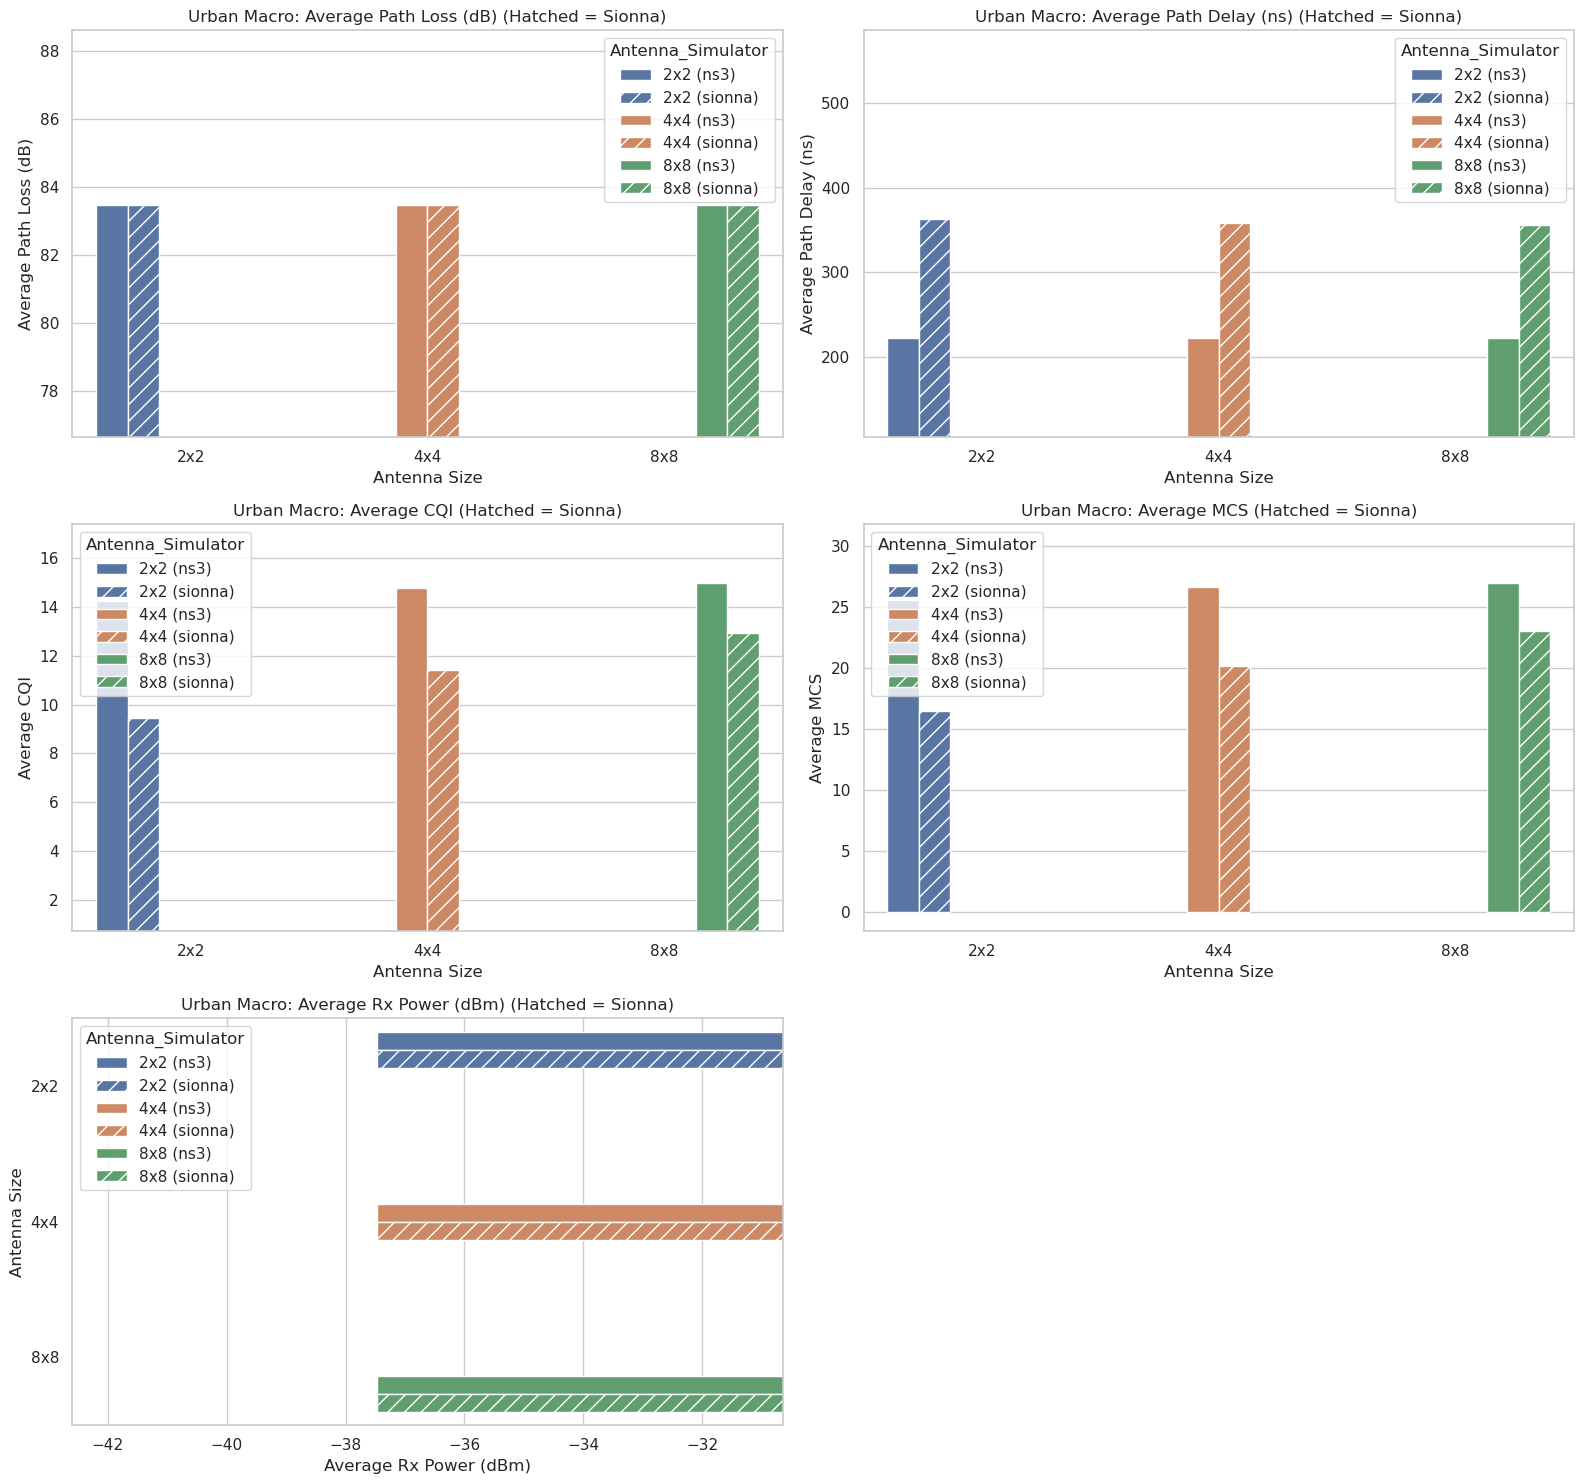

In [10]:

selected_scenario = 'urban_macro'
df_prop_plot = df_prop_nodes[df_prop_nodes['Scenario'] == selected_scenario].copy()
if df_prop_plot.empty:
    print(f"No propagation data for {selected_scenario}")
else:
    metrics = [
        ('FreeSpacePathloss_dB', 'Average Path Loss (dB)'),
        ('MeanPathDelay_ns', 'Average Path Delay (ns)'),
        ('MeanCqi', 'Average CQI'),
        ('MeanMcs', 'Average MCS'),
        ('EstimatedRxPower_dBm', 'Average Rx Power (dBm)')
    ]
    antenna_order = ['2x2', '4x4', '8x8']
    
    hue_order_ant = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    axes_flat = axes.flatten()
    
    # Combined antenna and simulator column
    df_prop_plot['Antenna_Simulator'] = df_prop_plot['Antenna'] + ' (' + df_prop_plot['Simulator'] + ')'
    
    for i, (metric_col, metric_label) in enumerate(metrics):
        ax = axes_flat[i]
        
        # Calculate dynamic limits to highlight differences
        data_values = df_prop_plot[metric_col].dropna()
        if not data_values.empty:
            v_min, v_max = data_values.min(), data_values.max()
            v_range = v_max - v_min
            padding = v_range * 0.2 if v_range > 0 else abs(v_max) * 0.1 if v_max != 0 else 1.0
            
        if metric_col == 'EstimatedRxPower_dBm':
            # Horizontal orientation for Rx Power
            sns.barplot(data=df_prop_plot, y='Antenna', x=metric_col, order=antenna_order, 
                        hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax)
            ax.set_xlabel(metric_label)
            ax.set_ylabel('Antenna Size')
            if not data_values.empty:
                ax.set_xlim(v_min - padding, v_max + padding)
        else:
            # Vertical orientation for others
            sns.barplot(data=df_prop_plot, x='Antenna', y=metric_col, order=antenna_order, 
                        hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax)
            ax.set_ylabel(metric_label)
            ax.set_xlabel('Antenna Size')
            if not data_values.empty:
                ax.set_ylim(v_min - padding, v_max + padding)
                
        # Apply hatches to distinguish Simulators
        for idx, container in enumerate(ax.containers):
            if idx < len(hue_order_ant):
                label = hue_order_ant[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
                    
        # Apply hatches to legend
        legend = ax.get_legend()
        if legend is not None:
            handles = getattr(legend, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_ant):
                    label = hue_order_ant[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} (Hatched = Sionna)')
    
    # Hide the empty 6th subplot
    if len(metrics) < len(axes_flat):
        axes_flat[-1].set_visible(False)
        
    plt.tight_layout()
    plt.show()


### Urban Macro: Flow Metrics

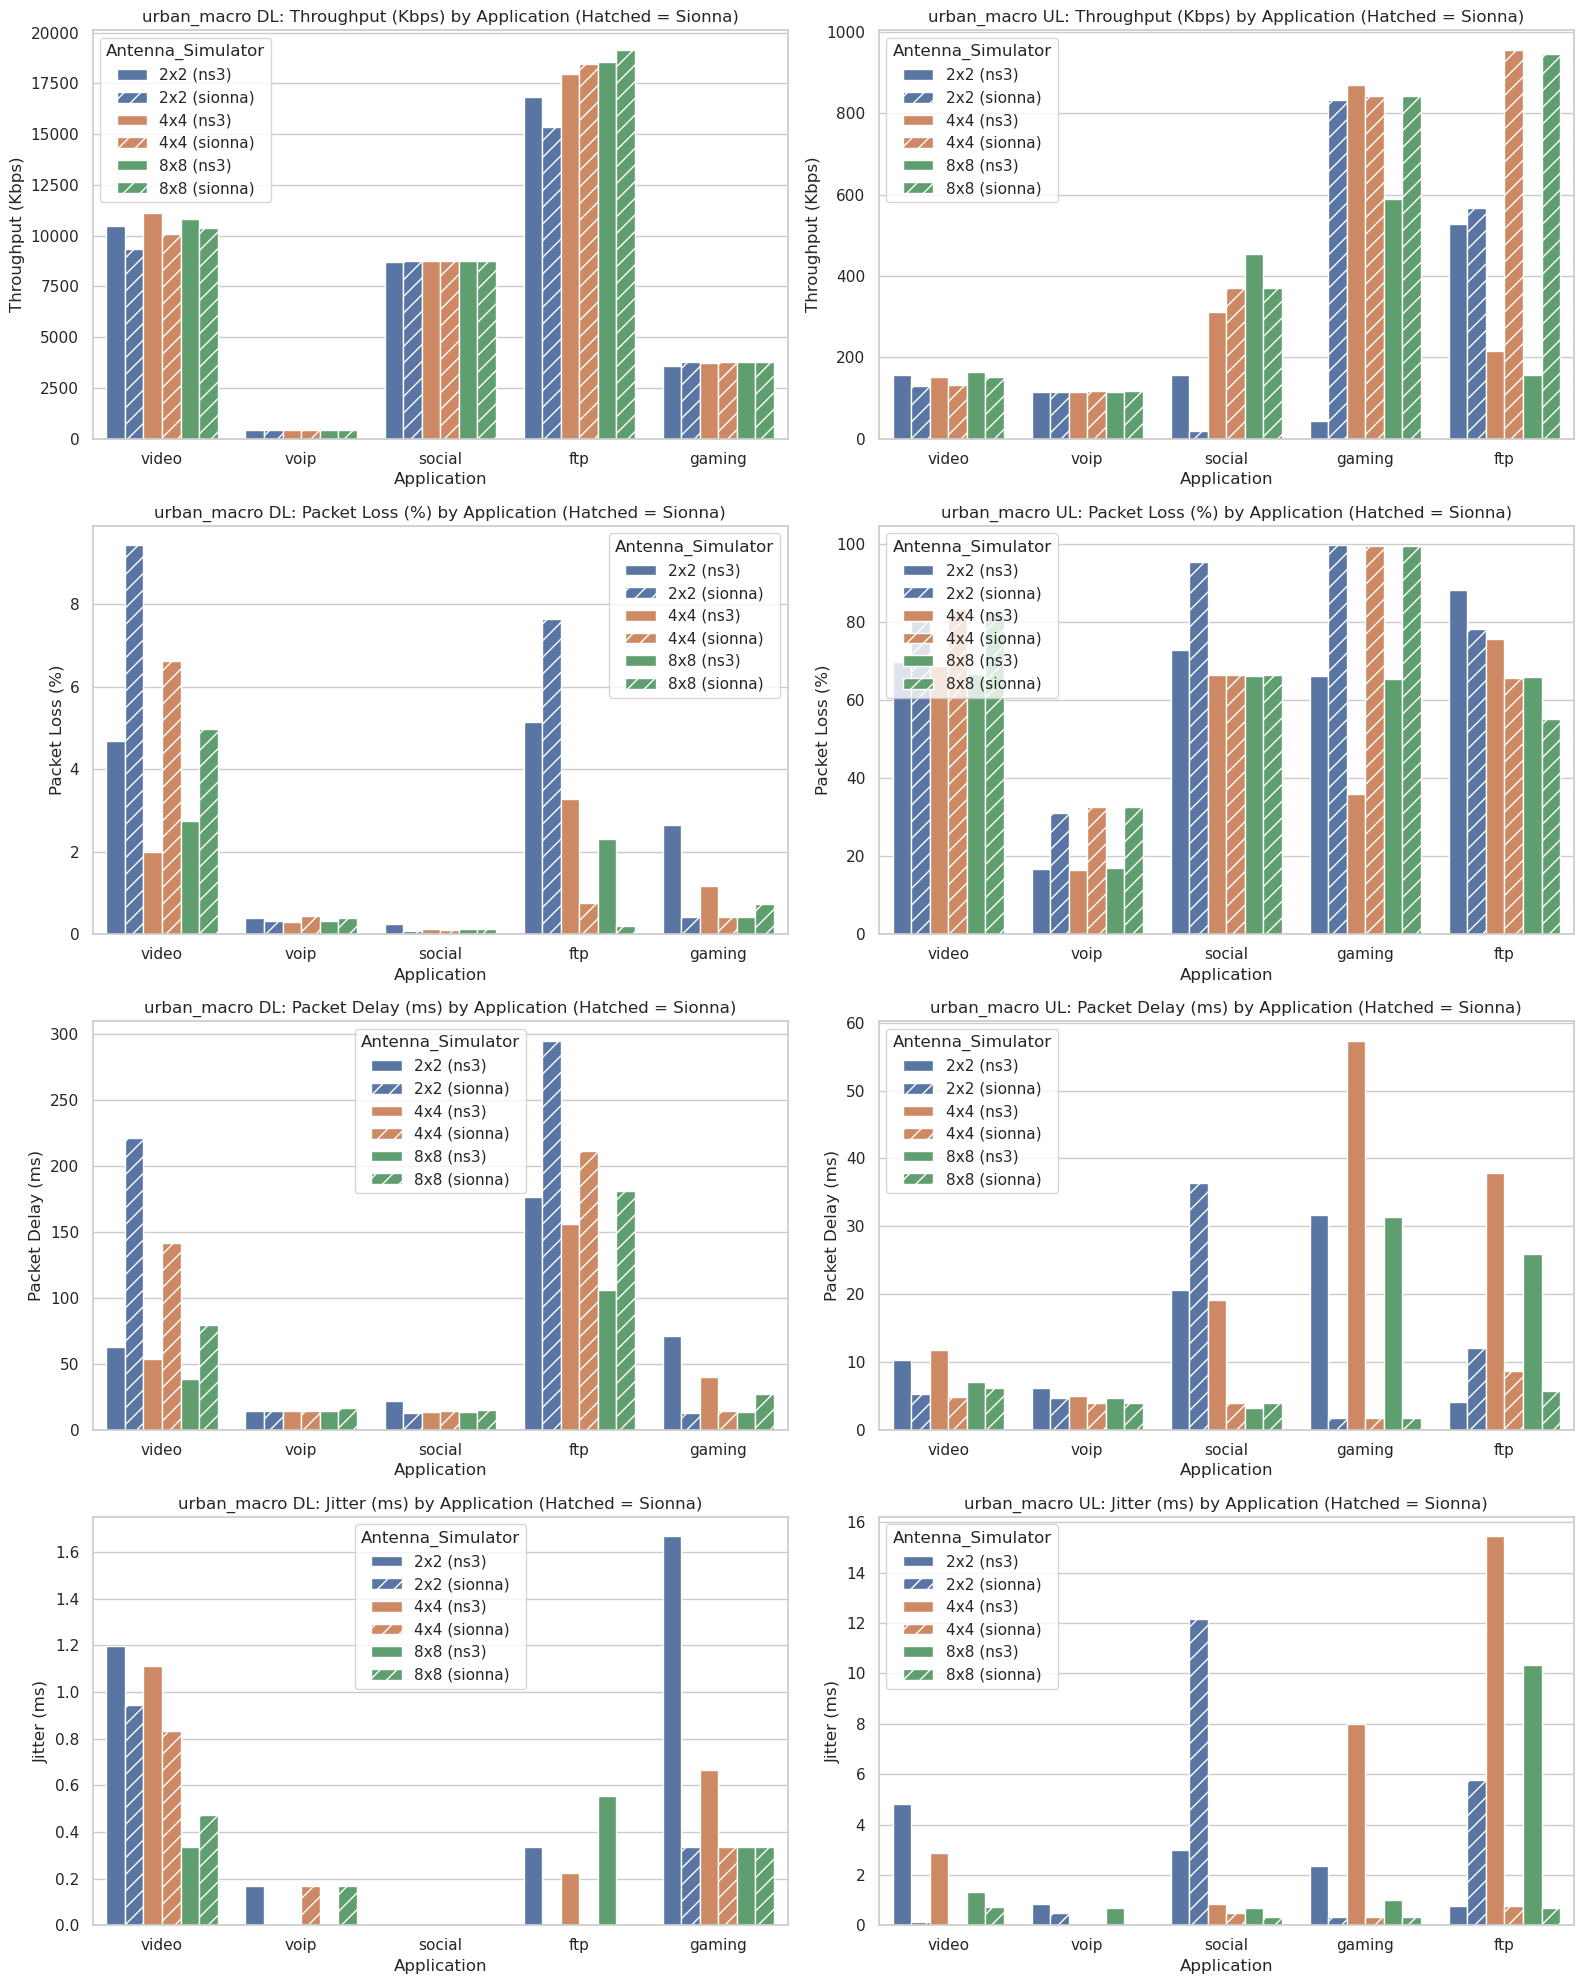

In [11]:

selected_scenario = 'urban_macro'
df_flow_plot = df_flows[df_flows['Scenario'] == selected_scenario].copy()
if df_flow_plot.empty:
    print(f"No flow data for {selected_scenario}")
else:
    metrics = [
        ('Throughput_Kbps', 'Throughput (Kbps)'),
        ('PacketLoss_pct', 'Packet Loss (%)'),
        ('Delay_ms', 'Packet Delay (ms)'),
        ('Jitter_ms', 'Jitter (ms)')
    ]
    directions = ['DL', 'UL']
    hue_order = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]
    
    fig, axes = plt.subplots(len(metrics), 2, figsize=(16, 5 * len(metrics)))
    for i, (metric_col, metric_label) in enumerate(metrics):
        for j, direction in enumerate(directions):
            ax = axes[i, j]
            df_plot = df_flow_plot[df_flow_plot['Direction'] == direction].copy()
            if df_plot.empty:
                ax.set_title(f'{selected_scenario} {direction}: No Data')
                continue
            
            # Combine Antenna and Simulator for grouped bar plot
            df_plot['Antenna_Simulator'] = df_plot['Antenna'] + ' (' + df_plot['Simulator'] + ')'
            
            sns.barplot(data=df_plot, x='Application', y=metric_col, hue='Antenna_Simulator', 
                        hue_order=hue_order, palette=custom_palette, errorbar=None, ax=ax)
            
            # Apply hatches to distinguish Simulators
            for idx, container in enumerate(ax.containers):
                if idx < len(hue_order):
                    label = hue_order[idx]
                    hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                    for patch in container:
                        patch.set_hatch(hatch)
            
            # Apply hatches to legend
            legend = ax.get_legend()
            if legend is not None:
                handles = getattr(legend, 'legend_handles', None)
                if handles is None:
                    handles = getattr(legend, 'legendHandles', [])
                for idx, handle in enumerate(handles):
                    if idx < len(hue_order):
                        label = hue_order[idx]
                        if 'sionna' in label or 'sionnart' in label:
                            handle.set_hatch('//')
            
            ax.set_title(f'{selected_scenario} {direction}: {metric_label} by Application (Hatched = Sionna)')
            ax.set_ylabel(metric_label)
    plt.tight_layout()
    plt.show()


### Urban Macro: Power Consumption

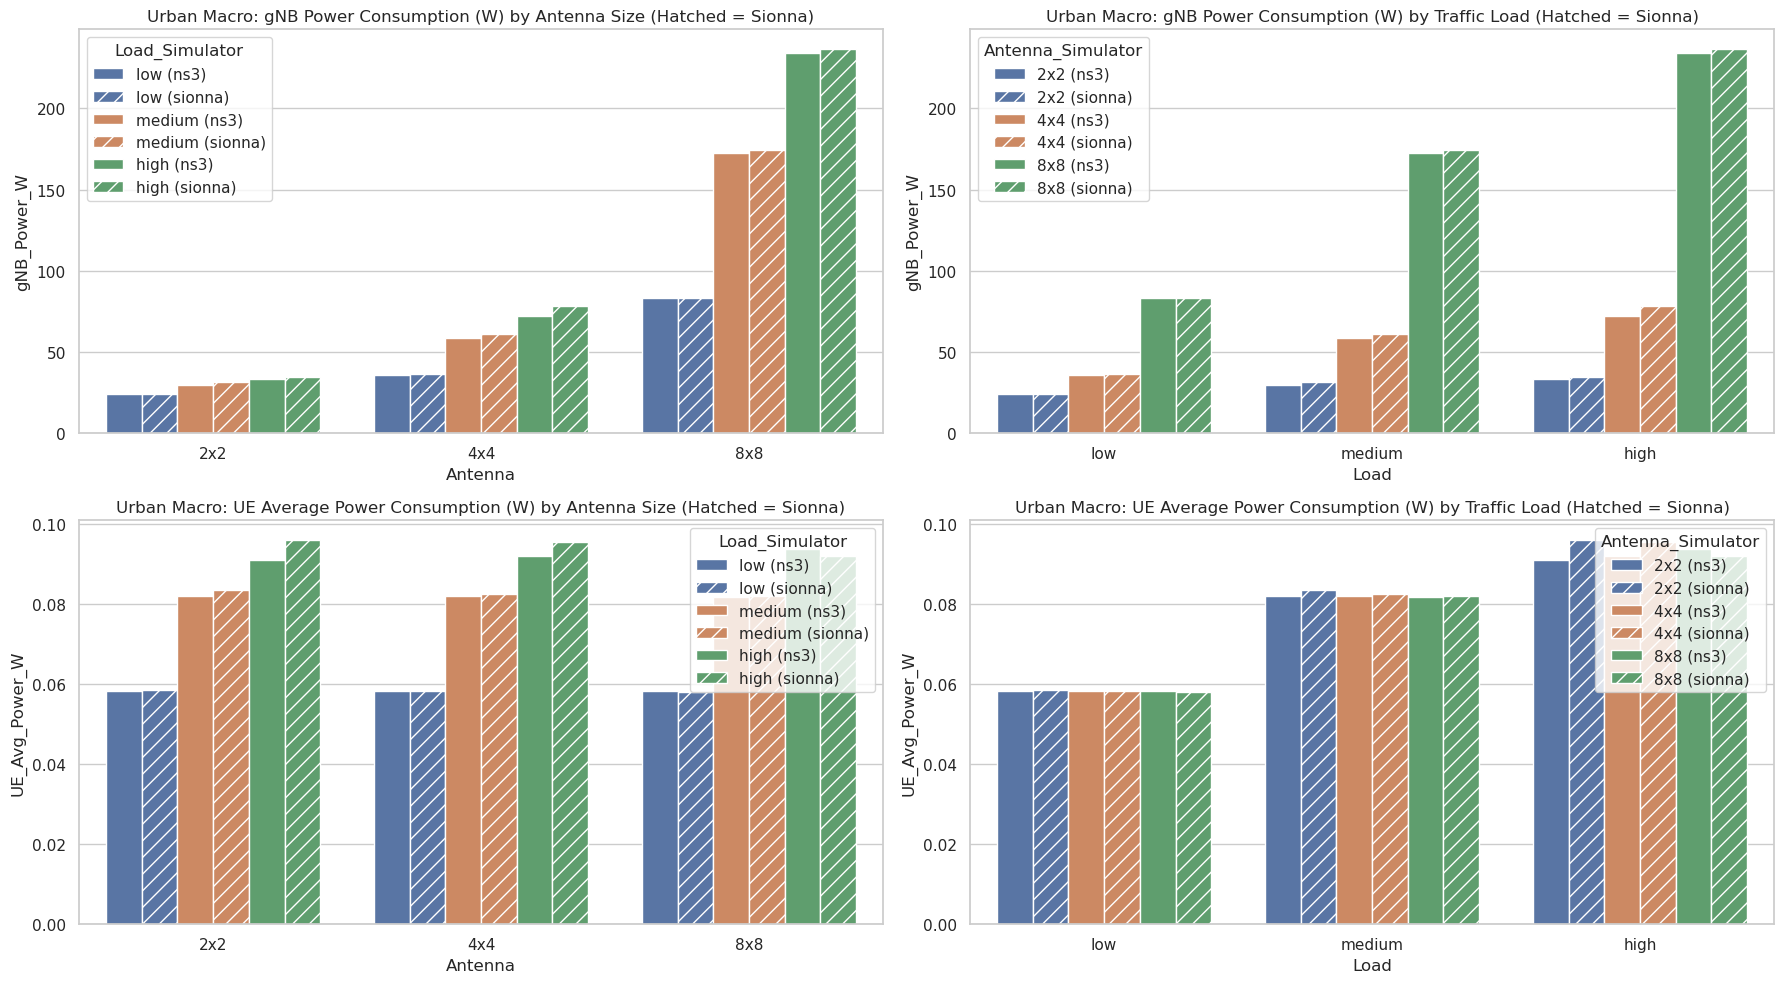

In [12]:

selected_scenario = 'urban_macro'
df_energy_scenario = df_energy[df_energy['Scenario'] == selected_scenario].copy()
if df_energy_scenario.empty:
    print(f"No energy data for {selected_scenario}")
else:
    metrics = [
        ('gNB_Power_W', 'gNB Power Consumption (W)'),
        ('UE_Avg_Power_W', 'UE Average Power Consumption (W)')
    ]
    antenna_order = ['2x2', '4x4', '8x8']
    load_order = ['low', 'medium', 'high']
    
    hue_order_load = ['low (ns3)', 'low (sionna)', 'medium (ns3)', 'medium (sionna)', 'high (ns3)', 'high (sionna)']
    hue_order_ant = ['2x2 (ns3)', '2x2 (sionna)', '4x4 (ns3)', '4x4 (sionna)', '8x8 (ns3)', '8x8 (sionna)']
    
    default_colors = sns.color_palette("deep", 3)
    custom_palette = [
        default_colors[0], default_colors[0],
        default_colors[1], default_colors[1],
        default_colors[2], default_colors[2]
    ]

    fig, axes = plt.subplots(len(metrics), 2, figsize=(18, 5 * len(metrics)))

    for i, (metric_col, metric_label) in enumerate(metrics):
        # Combined load and simulator column
        df_energy_scenario['Load_Simulator'] = df_energy_scenario['Load'] + ' (' + df_energy_scenario['Simulator'] + ')'
        
        # Plot 1: by Antenna Size (hue is Load + Simulator)
        ax1 = axes[i, 0]
        sns.barplot(data=df_energy_scenario, x='Antenna', y=metric_col, order=antenna_order, 
                    hue='Load_Simulator', hue_order=hue_order_load, palette=custom_palette, errorbar=None, ax=ax1)
        
        # Apply hatches to distinguish Simulators in Plot 1
        for idx, container in enumerate(ax1.containers):
            if idx < len(hue_order_load):
                label = hue_order_load[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
        
        # Apply hatches to legend of Plot 1
        legend1 = ax1.get_legend()
        if legend1 is not None:
            handles = getattr(legend1, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend1, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_load):
                    label = hue_order_load[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax1.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} by Antenna Size (Hatched = Sionna)')
        
        # Combined antenna and simulator column
        df_energy_scenario['Antenna_Simulator'] = df_energy_scenario['Antenna'] + ' (' + df_energy_scenario['Simulator'] + ')'
        
        # Plot 2: by Traffic Load (hue is Antenna + Simulator)
        ax2 = axes[i, 1]
        sns.barplot(data=df_energy_scenario, x='Load', y=metric_col, order=load_order, 
                    hue='Antenna_Simulator', hue_order=hue_order_ant, palette=custom_palette, errorbar=None, ax=ax2)
        
        # Apply hatches to distinguish Simulators in Plot 2
        for idx, container in enumerate(ax2.containers):
            if idx < len(hue_order_ant):
                label = hue_order_ant[idx]
                hatch = '//' if 'sionna' in label or 'sionnart' in label else ''
                for patch in container:
                    patch.set_hatch(hatch)
                    
        # Apply hatches to legend of Plot 2
        legend2 = ax2.get_legend()
        if legend2 is not None:
            handles = getattr(legend2, 'legend_handles', None)
            if handles is None:
                handles = getattr(legend2, 'legendHandles', [])
            for idx, handle in enumerate(handles):
                if idx < len(hue_order_ant):
                    label = hue_order_ant[idx]
                    if 'sionna' in label or 'sionnart' in label:
                        handle.set_hatch('//')
                        
        ax2.set_title(f'{selected_scenario.replace("_", " ").title()}: {metric_label} by Traffic Load (Hatched = Sionna)')

    plt.tight_layout()
    plt.show()
